<a href="https://colab.research.google.com/github/YenugulaRamya/my-colab-projects/blob/main/foundations_of_quantum_optimization_wiser.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 104.2 MB/s eta 0:00:00


In [ ]:
import pennylane as qp
from pennylane import numpy as pnp
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"]="STIXGeneral"
np.random.seed(42)
qp.about()

Name: pennylane
Version: 0.44.1
Summary: PennyLane is a cross-platform Python library for quantum computing, quantum machine learning, and quantum chemistry. Train a quantum computer the same way as a neural network.
Home-page: 
Author: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Platform info:           Linux-6.6.113+-x86_64-with-glibc2.35
Python version:          3.12.13
Numpy version:           2.0.2
Scipy version:           1.16.3
JAX version:             0.7.2
Installed devices:
- default.clifford (pennylane-0.44.1)
- default.gaussian (pennylane-0.44.1)
- default.mixed (pennylane-0.44.1)
- default.qubit (pennylane-0.44.1)
- default.qutrit (pennylane-0.44.1)
- default.qutrit.mixed (pennylane-0.44.1)
- default.tensor (pennylane-0.44.1)
- null.qubit (pennylane-0.44.1)
- reference.qubit (pennylane-0.44.1)
- lightning.qubit (pennylane_lightning-0.44.0)


In [ ]:
for n in [5,10,20,50,100]:
  print(f"{n:3d} bits -> {2**n:>30,d} candidate bit-strings")

  5 bits ->                             32 candidate bit-strings
 10 bits ->                          1,024 candidate bit-strings
 20 bits ->                      1,048,576 candidate bit-strings
 50 bits ->          1,125,899,906,842,624 candidate bit-strings
100 bits -> 1,267,650,600,228,229,401,496,703,205,376 candidate bit-strings


In [ ]:
def count_ones(bitstring):
  return sum(bitstring)
for bs in [(0,0,0),(1,0,1),(1,1,1)]:
  print(f"x={bs} score={count_ones(bs)}")

x=(0, 0, 0) score=0
x=(1, 0, 1) score=2
x=(1, 1, 1) score=3


In [ ]:
  B=np.array([
      [1,1,0],[0,1,1],[1,0,1],
  ])
  v=np.array([1,0,1])
  n_bits=B.shape[1]
  n_constraints=B.shape[0]
  print("B=\n",B)
  print("v=",v)

B=
 [[1 1 0]
 [0 1 1]
 [1 0 1]]
v= [1 0 1]


In [ ]:
import itertools
import numpy as np

# Define matrix B and target vector v
B = np.array([
    [1, 0, 1],
    [0, 1, 1],
    [1, 1, 0]
])

v = np.array([1, 1, 1])  # target vector

n = B.shape[1]  # number of bits

best_score = -1
best_x = None

print(" x       | Bx mod 2 | matches v? | score")
print("------------------------------------------")

# Generate all binary combinations
for bits in itertools.product([0, 1], repeat=n):
    x = np.array(bits)

    # Compute Bx mod 2
    result = np.mod(B @ x, 2)

    # Compare with target v
    matches = (result == v).astype(int)
    score = np.sum(matches)

    print(f"{list(x)} | {list(result)} | {list(matches)} | {score}")

    # Track best solution
    if score > best_score:
        best_score = score
        best_x = x

print("\nBest classical solution:")
print(f"x = {list(best_x)} with score = {best_score}/{len(v)}")

 x       | Bx mod 2 | matches v? | score
------------------------------------------
[np.int64(0), np.int64(0), np.int64(0)] | [np.int64(0), np.int64(0), np.int64(0)] | [np.int64(0), np.int64(0), np.int64(0)] | 0
[np.int64(0), np.int64(0), np.int64(1)] | [np.int64(1), np.int64(1), np.int64(0)] | [np.int64(1), np.int64(1), np.int64(0)] | 2
[np.int64(0), np.int64(1), np.int64(0)] | [np.int64(0), np.int64(1), np.int64(1)] | [np.int64(0), np.int64(1), np.int64(1)] | 2
[np.int64(0), np.int64(1), np.int64(1)] | [np.int64(1), np.int64(0), np.int64(1)] | [np.int64(1), np.int64(0), np.int64(1)] | 2
[np.int64(1), np.int64(0), np.int64(0)] | [np.int64(1), np.int64(0), np.int64(1)] | [np.int64(1), np.int64(0), np.int64(1)] | 2
[np.int64(1), np.int64(0), np.int64(1)] | [np.int64(0), np.int64(1), np.int64(1)] | [np.int64(0), np.int64(1), np.int64(1)] | 2
[np.int64(1), np.int64(1), np.int64(0)] | [np.int64(1), np.int64(1), np.int64(0)] | [np.int64(1), np.int64(1), np.int64(0)] | 2
[np.int64(1), np.int

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 81.7 MB/s eta 0:00:00


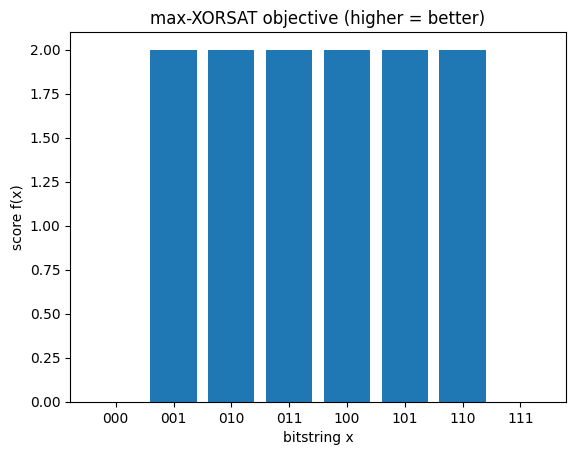

In [ ]:
# Install if needed:
!pip install qiskit matplotlib qiskit-aer

import numpy as np
import itertools
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer.primitives import Sampler # Changed import to qiskit_aer.primitives

# Define problem (same as your previous one)
B = np.array(
    [
        [1, 0, 1],
        [0, 1, 1],
        [1, 1, 0]
    ]
)

v = np.array([1, 1, 1])
n = B.shape[1]

# Function to compute score
def compute_score(x):
    result = np.mod(B @ x, 2)
    return np.sum(result == v)

# Generate all bitstrings
bitstrings = list(itertools.product([0, 1], repeat=n))
scores = []

for bits in bitstrings:
    x = np.array(bits)
    score = compute_score(x)
    scores.append(score)

# Convert bitstrings to labels
labels = [''.join(map(str, b)) for b in bitstrings]

# Plot
plt.figure()
plt.bar(labels, scores)
plt.xlabel("bitstring x")
plt.ylabel("score f(x)")
plt.title("max-XORSAT objective (higher = better)")
plt.show()

In [ ]:
!pip install pennylane
import pennylane as qp
import numpy as np

def cost_hamiltonian(B, v):
    """Build the max-XORSAT cost Hamiltonian.
    Eigenvalue = number of UNSATISFIED constraints.
    """
    n_bits = B.shape[1]
    n_constraints = B.shape[0]

    coeffs = [0.5 * n_constraints]
    ops = [qp.Identity(0)]

    for j in range(n_constraints):
        # Find variables involved in constraint j
        support = [i for i in range(n_bits) if B[j, i] == 1]

        # sign = (-1)^v[j]
        sign = (-1) ** int(v[j])

        # 1/2 * (I - sign * Z_i1 Z_i2 ...)
        if support:
            term = qp.Z(support[0])
            for i in support[1:]:
                term = term @ qp.Z(i)

            coeffs.append(-0.5 * sign)
            ops.append(term)

    return qp.Hamiltonian(coeffs, ops)


# Example input
B = np.array(
    [
        [1, 0, 1],
        [0, 1, 1],
        [1, 1, 0]
    ]
)

v = np.array([1, 1, 1])

# Build Hamiltonian
H_C = cost_hamiltonian(B, v)

print(H_C)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 103.6 MB/s eta 0:00:00
1.5 * I(0) + 0.5 * (Z(0) @ Z(2)) + 0.5 * (Z(1) @ Z(2)) + 0.5 * (Z(0) @ Z(1))
